# 18 — Análisis de una liga (Bundesliga): plantillas, porteros, impacto en cancha y fantasy

Hay **un notebook por liga** (`18_analisis_liga_<liga>.ipynb`), todos con el mismo código: solo cambian el parámetro
`LIGA` (primera celda de código) y los textos de interpretación, que se escriben después de ver los resultados de
cada liga. Las figuras se guardan con el nombre de la liga en `output/figures/ligas/`, así que no se pisan. La misma
lógica alimenta la página web del análisis (`scripts/export_analisis_liga.py`).

**Datos**: el dataset unificado de la Fase 19 — tabla estándar + `playingtime` + `keepers` de FBref, 16 temporadas
(2010-11 a 2025-26). Se usa en dos niveles:

- **jugador-equipo-temporada** (`filas`) para todo lo que es de un *equipo*: si un jugador se fue a mitad de
  temporada, sus minutos cuentan para cada uno de sus dos equipos;
- **jugador-temporada** (`jt`) para todo lo que es de un *jugador*.

**Secciones**

1. **Plantillas y rotación** — cuántos jugadores usa cada equipo, qué tan concentrados están los minutos, edad y
   extranjeros, temporada por temporada.
2. **Porteros** — % de paradas, porterías a cero y goles recibidos, de la liga y de cada portero.
3. **Impacto en cancha** — ¿qué dicen el +/− y el "con/sin él" de un jugador? (solo desde 2014-15).
4. **Fantasy y dependencia** — cuánto depende cada equipo de su goleador y de su mejor jugador fantasy.

**Lo que conviene recordar al leer**: una celda vacía es "FBref no tiene el dato" (no cero). En esta liga-temporada
pueden faltar datos según la época — el diccionario `data/processed/jugadores_temporada_2010_2026_diccionario.csv`
dice desde cuándo existe cada columna. Toda la lógica está en `futbol_bd/liga.py` (probada en `tests/test_liga.py`).

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import spearmanr

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ))
from futbol_bd import estilo, fantasy, liga, plantillas

# ======================================================================================================================
LIGA = "Bundesliga"
# ======================================================================================================================

SLUG = LIGA.lower().replace(" ", "_")
FIGURAS = RAIZ / "output" / "figures" / "ligas"
FIGURAS.mkdir(parents=True, exist_ok=True)
estilo.aplicar()
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 200)

## 0. Los datos de la liga

Se construyen las dos tablas con las funciones del paquete (las mismas que generan el CSV unificado) y se agrega el
resumen por equipo-temporada (`liga.resumen_equipos`). Antes de analizar nada, un control de calidad: cada equipo debe
sumar ≈ partidos × 990 minutos (11 jugadores × 90 minutos por partido; un poco menos si hubo expulsiones). Si faltaran
jugadores en el scrapeo, este cociente quedaría claramente por debajo de 1.

In [2]:
filas = plantillas.unir_tablas_extra(plantillas.limpiar_panel(plantillas.cargar_panel_crudo()))
jt = fantasy.puntos_fantasy(plantillas.agregar_por_temporada(filas))
# Percentil fantasy dentro de liga-temporada-posición (900+ minutos), como en el notebook 17.
jt["pct_pts_jornada"] = fantasy.percentil_en_grupo(jt, "pts_por_jornada")
filas, jt = filas[filas["league"] == LIGA], jt[jt["league"] == LIGA]
equipos = liga.resumen_equipos(filas, LIGA)
TEMPORADAS = sorted(equipos["temporada_inicio"].unique())

control = equipos.assign(cobertura_minutos=equipos["minutos"] / (equipos["pj"] * 990)).groupby("season").agg(
    equipos=("team_id", "size"), partidos_por_equipo=("pj", "median"), jugadores=("jugadores_usados", "sum"),
    cobertura_minutos_min=("cobertura_minutos", "min"), cobertura_minutos_mediana=("cobertura_minutos", "median"))
print(f"{LIGA}: {len(jt):,} jugador-temporadas, {jt['id_jugador'].nunique():,} jugadores, "
      f"{equipos['team_id'].nunique()} equipos distintos en {len(TEMPORADAS)} temporadas")
control.round(3)

Bundesliga: 7,698 jugador-temporadas, 2,498 jugadores, 32 equipos distintos en 16 temporadas


,equipos,partidos_por_equipo,jugadores,cobertura_minutos_min,cobertura_minutos_mediana
season,,,,,
2010-2011,18,34.0,477,0.994,0.998
2011-2012,18,34.0,489,0.990,0.998
2012-2013,18,34.0,479,0.993,0.997
2013-2014,18,34.0,476,0.995,0.998
2014-2015,18,34.0,462,0.995,0.999
2015-2016,18,34.0,492,0.997,0.998
2016-2017,18,34.0,475,0.993,0.999
2017-2018,18,34.0,484,0.994,0.999
2018-2019,18,34.0,474,0.993,0.998


18 equipos y 34 partidos en las 16 temporadas; 7,698 jugador-temporadas de 2,498 jugadores en 32 clubes. Cobertura de
minutos del 99.0% al 99.9% y ningún equipo con resultados no confiables: es el panel más limpio de las siete ligas.

## 1. Plantillas y rotación

Cuatro medidas por equipo-temporada (definidas en `liga.resumen_equipos`):

- **jugadores usados**: cuántos jugadores tuvieron minutos;
- **jugadores para el 80% de los minutos**: concentración. Con un once fijo serían ~11-12; si el técnico rota, más.
  Es más robusta que "jugadores usados", que sube con cualquier debutante de 5 minutos;
- **edad ponderada por minutos**: la edad de *quien juega*, no la de la lista;
- **% de minutos de extranjeros** (nacionalidad deportiva según FBref, ver `liga.NACIONALES`).

La figura muestra, por temporada, la **mediana** de los equipos (línea) y el rango donde está la mitad central de los
equipos (banda, percentiles 25-75). Mediana y no promedio: un equipo con una temporada rara no mueve la tendencia.

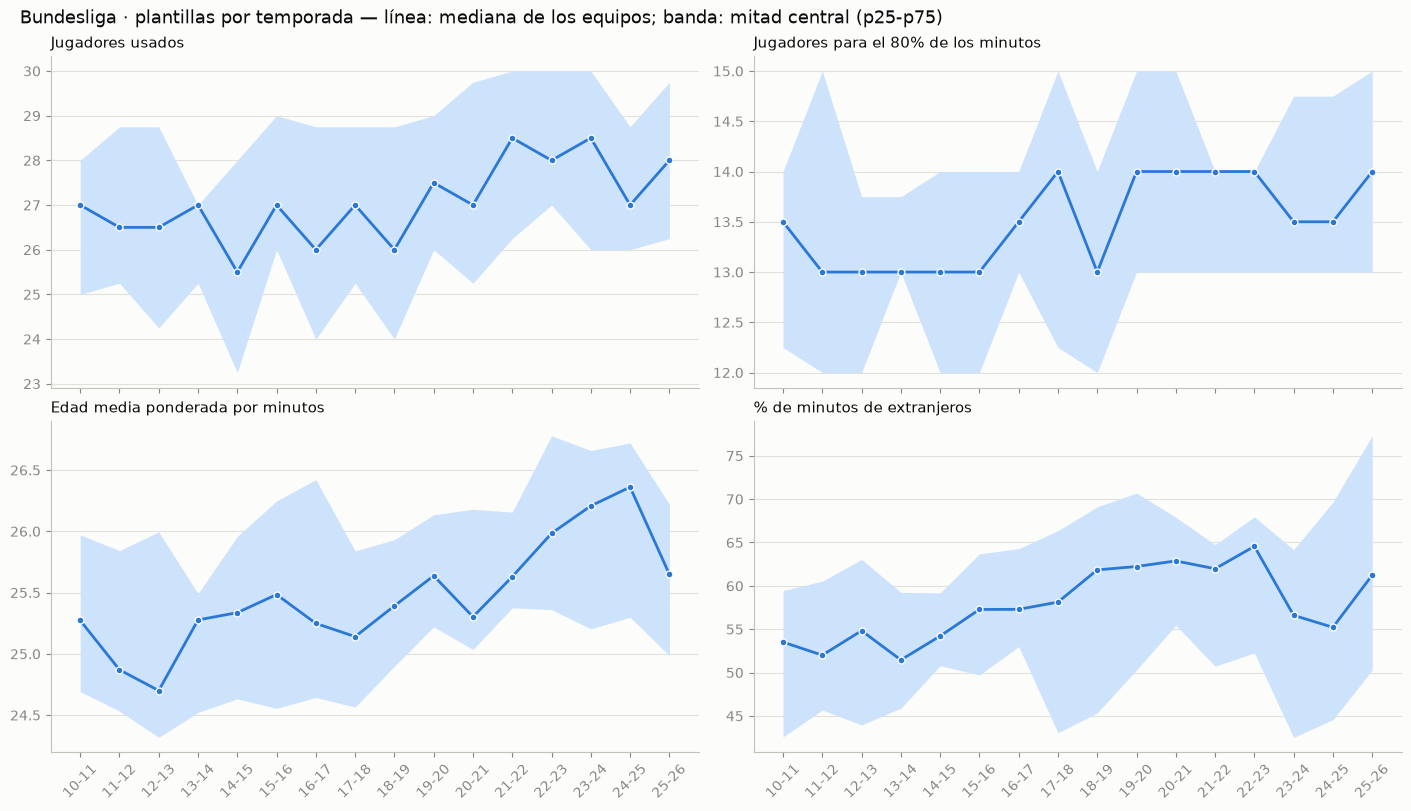

In [3]:
metricas = {"jugadores_usados": "Jugadores usados", "jugadores_80pct": "Jugadores para el 80% de los minutos",
            "edad_ponderada": "Edad media ponderada por minutos", "pct_min_extranjeros": "% de minutos de extranjeros"}
tendencia = liga.tendencia_liga(equipos, list(metricas))

fig, axs = plt.subplots(2, 2, figsize=(14, 8), sharex=True, constrained_layout=True)
for ax, (col, titulo) in zip(axs.ravel(), metricas.items()):
    ax.fill_between(TEMPORADAS, tendencia[("p25", col)], tendencia[("p75", col)], color=estilo.AZUL_CLARO, linewidth=0)
    ax.plot(TEMPORADAS, tendencia[("mediana", col)], color=estilo.AZUL, linewidth=2, marker="o", markersize=5,
            markeredgecolor=estilo.SUPERFICIE)
    ax.set_title(titulo)
    estilo.rejilla_y(ax)
for ax in axs[1]:
    estilo.etiquetas_temporada(ax, TEMPORADAS)
fig.suptitle(f"{LIGA} · plantillas por temporada — línea: mediana de los equipos; banda: mitad central (p25-p75)",
             x=0.01, ha="left", fontsize=13, color=estilo.TINTA)
fig.savefig(FIGURAS / f"{SLUG}_plantillas.png", dpi=150)
plt.show()

- **La rotación más estable de todas**: 13-14 jugadores para el 80% de los minutos en las 16 temporadas, sin
  tendencia.
- **La liga de los jóvenes**: la edad de quien juega se mueve entre 24.7 y 26.4 años, y los minutos de jugadores de 21
  años o menos van del 11% al 21.7% — muy por encima de la Premier (6-12.7%) y la Liga MX (5-13%), aunque por debajo
  de la Eredivisie.
- **Extranjeros**: del 51.5% al 64.6% de los minutos, con una caída en 2023-25 (55-57%) y repunte a 61.2% en 2025-26.

In [4]:
# Los extremos de todo el periodo: los equipos que más rotaron (más jugadores para cubrir el 80% de los minutos) y los
# que menos. Se muestra también el resultado (puntos por partido) para ver si rotar se asocia con ganar o perder.
columnas = ["season", "equipo", "jugadores_usados", "jugadores_80pct", "edad_ponderada", "pct_min_extranjeros", "ppg"]
print("Más rotación:")
display(equipos.nlargest(6, "jugadores_80pct")[columnas].round(1))
print("Menos rotación:")
display(equipos.nsmallest(6, "jugadores_80pct")[columnas].round(1))
rho = spearmanr(equipos["jugadores_80pct"], equipos["ppg"], nan_policy="omit").statistic
print(f"Rotación vs puntos por partido (Spearman, todos los equipo-temporadas): {rho:.2f}")

Más rotación:


,season,equipo,jugadores_usados,jugadores_80pct,edad_ponderada,pct_min_extranjeros,ppg
195,2020-2021,Schalke 04,42,19,25.3,57.3,0.5
31,2011-2012,Freiburg,31,17,24.5,49.9,1.2
75,2014-2015,Hamburger SV,31,17,26.7,55.5,1.0
117,2016-2017,Darmstadt 98,31,17,27.1,39.5,0.7
139,2017-2018,Dortmund,30,17,25.4,64.0,1.6
140,2017-2018,Köln,31,17,24.8,43.0,0.6


Menos rotación:


,season,equipo,jugadores_usados,jugadores_80pct,edad_ponderada,pct_min_extranjeros,ppg
7,2010-2011,Hannover 96,23,11,25.1,59.1,1.8
13,2010-2011,Dortmund,23,11,22.9,49.0,2.2
23,2011-2012,Gladbach,25,11,25.2,60.2,1.8
52,2012-2013,Leverkusen,24,11,23.9,25.2,1.9
53,2012-2013,Frankfurt,27,11,24.4,42.9,1.5
59,2013-2014,Gladbach,21,11,25.2,51.1,1.6


Rotación vs puntos por partido (Spearman, todos los equipo-temporadas): -0.39


Rotar se asocia con perder con fuerza (**−0.39**). El caso extremo es el **Schalke 04 2020-21**: 19 jugadores para el
80% de los minutos y 0.5 puntos por partido, la peor temporada del periodo. Los que menos rotaron: **Dortmund
2010-11** (11 jugadores, 2.2 puntos por partido, campeón con la plantilla más joven del panel: 22.9 años de edad
ponderada), Hannover 2010-11 y Leverkusen 2012-13.

## 2. Porteros

Primero la liga completa: % de paradas (paradas / tiros a puerta recibidos), goles recibidos por partido y % de
partidos con portería a cero, sumando a todos los porteros antes de dividir (una tasa de la liga, no el promedio de
las tasas de cada portero). Después, cada portero en toda su carrera en la liga.

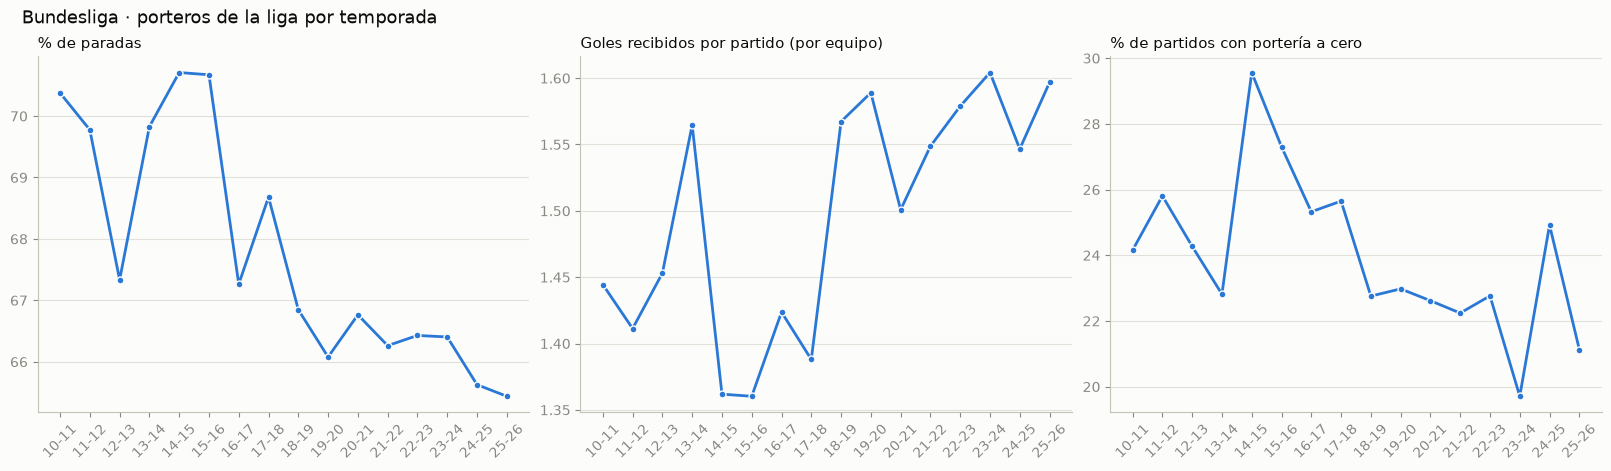

In [5]:
lp = liga.porteros_liga(jt, LIGA).reindex(TEMPORADAS)
paneles = {"pct_paradas": "% de paradas", "goles_recibidos_por_partido": "Goles recibidos por partido (por equipo)",
           "pct_porterias_cero": "% de partidos con portería a cero"}
fig, axs = plt.subplots(1, 3, figsize=(16, 4.6), sharex=True, constrained_layout=True)
for ax, (col, titulo) in zip(axs, paneles.items()):
    # Una temporada sin dato queda como hueco en la línea (no se une con la siguiente como si hubiera dato).
    ax.plot(TEMPORADAS, lp[col], color=estilo.AZUL, linewidth=2, marker="o", markersize=5,
            markeredgecolor=estilo.SUPERFICIE)
    faltan = [t for t in TEMPORADAS if pd.isna(lp.loc[t, col])]
    for t in faltan:
        ax.annotate("sin dato", (t, ax.get_ylim()[0]), xytext=(0, 4), textcoords="offset points", ha="center",
                    fontsize=8, color=estilo.TENUE)
    ax.set_title(titulo)
    estilo.rejilla_y(ax)
    estilo.etiquetas_temporada(ax, TEMPORADAS)
fig.suptitle(f"{LIGA} · porteros de la liga por temporada", x=0.01, ha="left", fontsize=13, color=estilo.TINTA)
fig.savefig(FIGURAS / f"{SLUG}_porteros_liga.png", dpi=150)
plt.show()

- **El % de paradas más bajo de las siete ligas**: cae de 70.4% (2010-11) a 65.4% (2025-26).
- **Y los goles recibidos más altos**: entre 1.36 y 1.60 por partido, con las temporadas recientes en la parte alta.
- **Porterías a cero**: las más escasas (19.7% a 29.6%).

La explicación más simple es que en la Bundesliga se marca más: no es que sus porteros sean peores, sino que reciben
más tiros y más goles.

In [6]:
# Carreras completas en la liga (mínimo 9,000 minutos ≈ 100 partidos): el % de paradas de toda la carrera pondera cada
# temporada por los tiros que recibió.
carreras = liga.carrera_porteros(jt, LIGA, min_minutos=9000)
columnas = ["portero", "equipos", "desde", "hasta", "partidos", "pct_paradas", "pct_porterias_cero", "goles_recibidos_90"]
display(carreras[columnas].head(12).round(2))

# ¿El % de paradas es del portero o de su defensa? Correlación entre una temporada y la siguiente (1,500+ minutos).
porteros_jt = jt[jt["gk_games"].notna()]
r_paradas, n_paradas, _ = liga.estabilidad(porteros_jt, "gk_save_pct", minutos="gk_minutes")
r_cero, n_cero, _ = liga.estabilidad(porteros_jt, "gk_clean_sheets_pct", minutos="gk_minutes")
print(f"Estabilidad año a año — % de paradas: r = {r_paradas:.2f} ({n_paradas} pares); "
      f"% porterías a cero: r = {r_cero:.2f} ({n_cero} pares)")

,portero,equipos,desde,hasta,partidos,pct_paradas,pct_porterias_cero,goles_recibidos_90
id_jugador,,,,,,,,
6f51e382,Marc-André ter Stegen,Gladbach,2010,2013,108.0,76.74,33.33,1.08
8778c910,Manuel Neuer,Schalke 04 / Bayern Munich,2010,2025,423.0,72.80,45.15,0.84
a92ab7be,Mark Flekken,Freiburg / Leverkusen,2018,2025,104.0,72.40,29.81,1.37
1e43fad8,Ralf Fährmann,Frankfurt / Schalke 04,2010,2022,224.0,72.25,26.79,1.36
2e7ff968,Marwin Hitz,Wolfsburg / Augsburg / Dortmund,2010,2021,176.0,71.59,30.68,1.34
16b8fabd,Roman Weidenfeller,Dortmund,2010,2017,161.0,71.09,34.16,0.99
420c18a1,Yann Sommer,Gladbach / Bayern Munich,2014,2022,291.0,70.38,25.77,1.38
9d12e142,Roman Bürki,Freiburg / Dortmund,2014,2021,210.0,69.79,32.86,1.26
a0606ae8,Ron-Robert Zieler,Hannover 96 / Stuttgart / Köln,2010,2020,254.0,69.64,22.44,1.59


Estabilidad año a año — % de paradas: r = 0.34 (178 pares); % porterías a cero: r = 0.39 (178 pares)


Entre los 31 porteros con 100+ partidos, el mejor % de paradas es de **Marc-André ter Stegen** (76.7%) en sus 108
partidos con el Gladbach antes de irse al Barcelona. **Manuel Neuer** domina las otras dos métricas con 423 partidos
(Schalke y Bayern): 45.2% de porterías a cero y 0.84 goles recibidos por 90.

Estabilidad año a año: % de paradas 0.34 y porterías a cero 0.39.

In [7]:
# La última temporada, porteros con 900+ minutos. Y un control de calidad: goles recibidos según la tabla de porteros
# vs. goles recibidos por su equipo con él en cancha (onGA). Deberían coincidir; donde no, FBref se contradice.
ultima = jt[(jt["temporada_inicio"] == TEMPORADAS[-1]) & (jt["gk_minutes"] >= 900)]
display(ultima.sort_values("gk_save_pct", ascending=False)[
    ["player", "equipo_principal", "gk_games", "gk_save_pct", "gk_clean_sheets", "gk_goals_against",
     "on_goals_against"]].round(1))

por_temporada = liga.desacuerdo_goles_porteros(porteros_jt)
print(f"Porteros-temporada con ambos datos: {por_temporada['porteros'].sum()}; no coinciden: "
      f"{por_temporada['no_coinciden'].sum()}. Por temporada:")
display(por_temporada.set_index("temporada_inicio").T)
con_ambos = porteros_jt[porteros_jt["on_goals_against"].notna()]
difiere = con_ambos[con_ambos["gk_goals_against"] != con_ambos["on_goals_against"]]
print("Los de mayor diferencia:")
display(difiere.assign(diferencia=difiere["on_goals_against"] - difiere["gk_goals_against"])
        .reindex(columns=["player", "season", "equipo_principal", "gk_games", "gk_goals_against", "on_goals_against",
                          "diferencia"])
        .sort_values("diferencia", key=abs, ascending=False).head(5))

,player,equipo_principal,gk_games,gk_save_pct,gk_clean_sheets,gk_goals_against,on_goals_against
7393,Janis Blaswich,Leverkusen,11.0,82.0,3.0,9.0,9.0
7295,Daniel Batz,Mainz 05,21.0,72.2,4.0,27.0,27.0
7361,Gregor Kobel,Dortmund,34.0,72.1,15.0,34.0,34.0
7548,Moritz Nicolas,Gladbach,34.0,72.0,13.0,53.0,53.0
7218,Alexander Nübel,Stuttgart,34.0,68.2,11.0,49.0,49.0
7417,Jonas Urbig,Bayern Munich,14.0,68.1,6.0,15.0,15.0
7510,Mark Flekken,Leverkusen,24.0,67.5,5.0,38.0,38.0
7565,Nikola Vasilj,St Pauli,34.0,67.2,5.0,60.0,60.0
7497,Maarten Vandevoordt,RB Leipzig,12.0,66.7,2.0,15.0,15.0
7297,Daniel Heuer Fernandes,Hamburger SV,33.0,66.5,6.0,53.0,53.0


Porteros-temporada con ambos datos: 417; no coinciden: 17. Por temporada:


temporada_inicio,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
no_coinciden,3,2,1,1,6,1,1,0,0,1,1,0
porteros,34,35,33,32,36,36,35,41,34,33,38,30


Los de mayor diferencia:


,player,season,equipo_principal,gk_games,gk_goals_against,on_goals_against,diferencia
2458,Felix Wiedwald,2015-2016,Werder Bremen,34.0,40.0,65.0,25.0
6230,Alexander Brunst,2023-2024,Darmstadt 98,3.0,10.0,16.0,6.0
4664,Sven Ulreich,2019-2020,Bayern Munich,2.0,1.0,6.0,5.0
6920,Jonas Omlin,2024-2025,Gladbach,12.0,29.0,26.0,-3.0
3864,Fabian Bredlow,2018-2019,Nürnberg,14.0,28.0,30.0,2.0


En 2025-26, con 900+ minutos, el mejor % de paradas es de Janis Blaswich (Leverkusen, 82.0%), aunque en solo 11
partidos; con temporada completa destacan **Gregor Kobel** (Dortmund, 72.1% y 15 porterías a cero en 34 partidos) y
Daniel Batz (Mainz, 72.2%). Los últimos: Frederik Rønnow (Union Berlin, 57.3%) y Kauã Santos (Frankfurt, 53.6%).

**Calidad de datos**: de 0 a 3 desacuerdos por temporada entre las dos tablas de FBref, salvo 2018-19 con 6.

## 3. Impacto en cancha

FBref publica, desde 2014-15, dos medidas de "qué pasa cuando el jugador está en la cancha":

- **on-off** (`plus_minus_wowy`): goles netos de su equipo por 90 minutos con él en cancha, menos sin él;
- **puntos por partido con él** (`points_per_game`). Aquí se compara con los puntos por partido de su equipo en toda
  la temporada: `ppg_extra` = puntos con él − puntos del equipo (solo jugadores con un solo equipo esa temporada, para
  que la comparación sea limpia).

Son tentadoras como medida de "impacto", pero están muy expuestas a cosas ajenas al jugador: con quién comparte
cancha, contra quién jugó, si solo entra cuando el partido está roto. Antes de usarlas hay que probar si miden algo
**del jugador**: si fuera así, quien sale alto una temporada tendería a salir alto la siguiente. Como referencia de lo
que se ve cuando una medida sí es del jugador, se agrega una métrica individual: goles sin penal por 90 de los
delanteros.

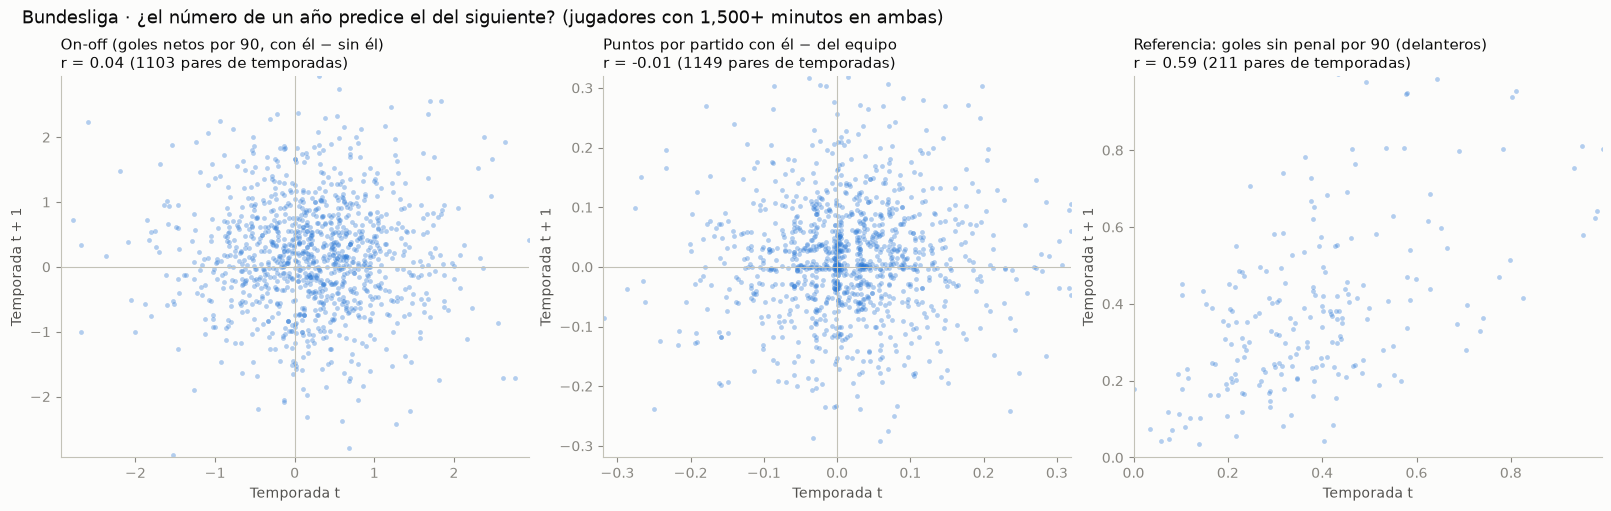

,r,pares
"On-off (goles netos por 90, con él − sin él)",0.04,1103.0
Puntos por partido con él − del equipo,-0.01,1149.0
Referencia: goles sin penal por 90 (delanteros),0.59,211.0


In [8]:
# ppg_extra = puntos por partido con él − del equipo; solo jugadores con un equipo en la temporada (ver docstring).
jt = liga.agregar_ppg_extra(jt, equipos)

pruebas = {
    "plus_minus_wowy": ("On-off (goles netos por 90, con él − sin él)", jt),
    "ppg_extra": ("Puntos por partido con él − del equipo", jt),
    "goals_pens_per90": ("Referencia: goles sin penal por 90 (delanteros)", jt[jt["pos_principal"] == "FW"]),
}
fig, axs = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True)
resumen_estabilidad = {}
for ax, (col, (titulo, datos)) in zip(axs, pruebas.items()):
    r, n, pares = liga.estabilidad(datos, col, min_minutos=1500)
    resumen_estabilidad[titulo] = {"r": round(r, 2), "pares": n}
    ax.scatter(pares[col], pares[f"{col}_siguiente"], s=12, color=estilo.AZUL, alpha=0.35, linewidths=0)
    lim = np.nanpercentile(np.abs(pares[[col, f"{col}_siguiente"]].to_numpy()), 99)
    if col == "goals_pens_per90":
        ax.set_xlim(0, lim); ax.set_ylim(0, lim)
    else:
        ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
        ax.axhline(0, color=estilo.EJE, linewidth=0.8); ax.axvline(0, color=estilo.EJE, linewidth=0.8)
    ax.set_title(f"{titulo}\nr = {r:.2f} ({n} pares de temporadas)")
    ax.set_xlabel("Temporada t"); ax.set_ylabel("Temporada t + 1")
fig.suptitle(f"{LIGA} · ¿el número de un año predice el del siguiente? (jugadores con 1,500+ minutos en ambas)",
             x=0.01, ha="left", fontsize=13, color=estilo.TINTA)
fig.savefig(FIGURAS / f"{SLUG}_impacto_estabilidad.png", dpi=150)
plt.show()
pd.DataFrame(resumen_estabilidad).T

| Medida | Correlación año a año |
|---|---|
| On-off (goles netos con él − sin él) | **0.04** (1,103 pares) |
| Puntos por partido con él − del equipo | **−0.01** (1,149 pares) |
| Referencia: goles sin penal por 90 (delanteros) | **0.59** (211 pares) |

Los puntos con el jugador en cancha llegan aquí a ser ligeramente **negativos**: saber cuántos puntos sumó su equipo
con él una temporada no dice absolutamente nada de la siguiente.

## 4. Fantasy y dependencia

Dos preguntas sobre cómo se reparte la producción dentro de cada equipo:

1. **Dependencia del goleador**: qué parte de los goles del equipo hizo su máximo goleador. ¿Depender de un solo
   jugador se asocia con sumar más o menos puntos?
2. **El mejor jugador fantasy de cada equipo** en la última temporada y qué parte de los puntos fantasy del equipo
   hizo (con el esquema ofensivo del notebook 17; los puntos de un jugador traspasado cuentan para su equipo
   principal).

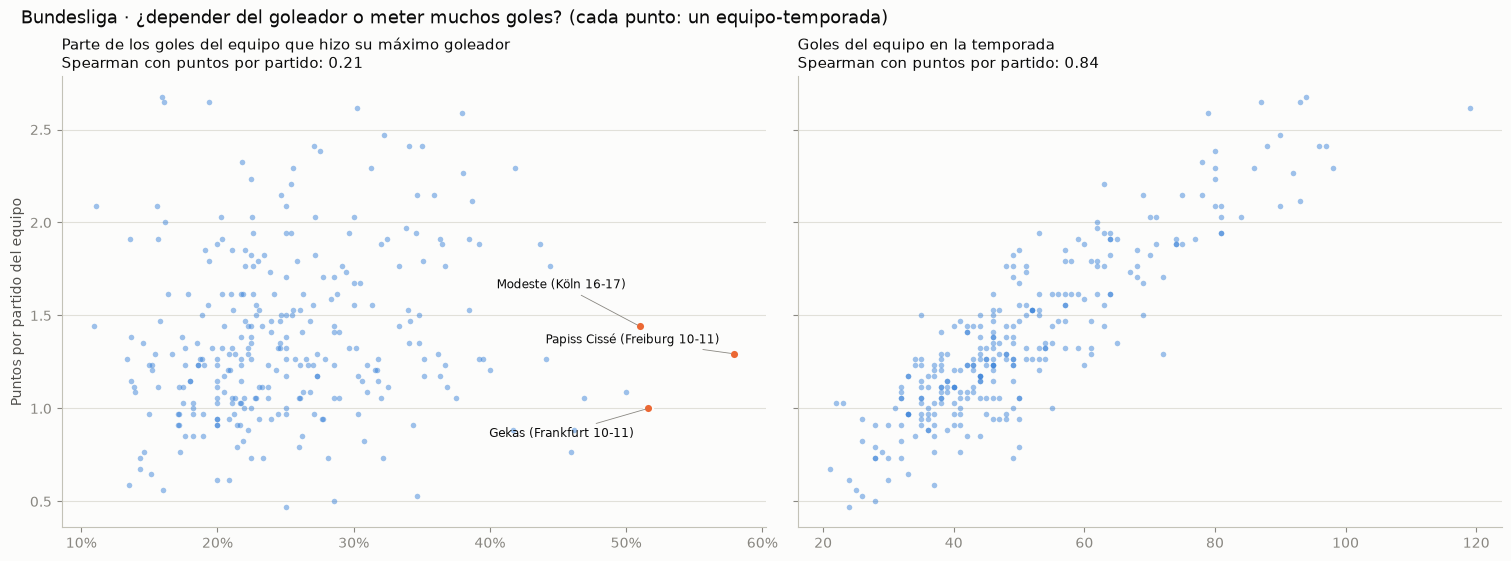

,season,equipo,goleador,goles_goleador,goles,dependencia_goleador,ppg
12,2010-2011,Freiburg,Papiss Cissé,22.0,38.0,0.58,1.29
17,2010-2011,Frankfurt,Theofanis Gekas,16.0,31.0,0.52,1.00
122,2016-2017,Köln,Anthony Modeste,25.0,49.0,0.51,1.44
115,2016-2017,Wolfsburg,Mario Gómez,16.0,32.0,0.50,1.09
137,2017-2018,Freiburg,Nils Petersen,15.0,32.0,0.47,1.06
33,2011-2012,Köln,Lukas Podolski,18.0,39.0,0.46,0.88
64,2013-2014,Nürnberg,Josip Drmić,17.0,37.0,0.46,0.76
197,2020-2021,Frankfurt,André Silva,28.0,63.0,0.44,1.76


Mediana de la dependencia por temporada: {'2010-2011': 0.25, '2011-2012': 0.27, '2012-2013': 0.22, '2013-2014': 0.25, '2014-2015': 0.23, '2015-2016': 0.28, '2016-2017': 0.24, '2017-2018': 0.22, '2018-2019': 0.23, '2019-2020': 0.23, '2020-2021': 0.22, '2021-2022': 0.25, '2022-2023': 0.23, '2023-2024': 0.25, '2024-2025': 0.25, '2025-2026': 0.23}


In [9]:
fig, axs = plt.subplots(1, 2, figsize=(15, 5.5), sharey=True, constrained_layout=True)
rho_dep = spearmanr(equipos["dependencia_goleador"], equipos["ppg"], nan_policy="omit").statistic
rho_gol = spearmanr(equipos["goles"], equipos["ppg"], nan_policy="omit").statistic
for ax, (col, titulo, rho, fmt) in zip(axs, [
        ("dependencia_goleador", "Parte de los goles del equipo que hizo su máximo goleador", rho_dep, "{:.0%}"),
        ("goles", "Goles del equipo en la temporada", rho_gol, "{:.0f}")]):
    ax.scatter(equipos[col], equipos["ppg"], s=16, color=estilo.AZUL, alpha=0.45, linewidths=0)
    ax.set_title(f"{titulo}\nSpearman con puntos por partido: {rho:.2f}")
    estilo.rejilla_y(ax)
    if col == "dependencia_goleador":
        ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
        # Se resaltan los 3 equipos más dependientes. Las etiquetas se escalonan en vertical porque dos de ellos tienen
        # exactamente 1.00 punto por partido y quedarían encimadas.
        for k, (_, e) in enumerate(equipos.nlargest(3, col).iterrows()):
            ax.scatter(e[col], e["ppg"], s=44, color=estilo.NARANJA, edgecolors=estilo.SUPERFICIE, linewidths=1.5,
                       zorder=3)
            nombre = e["goleador"] if len(e["goleador"]) <= 12 else e["goleador"].split()[-1]
            ax.annotate(f"{nombre} ({e['equipo']} {e['season'][2:4]}-{e['season'][7:]})", (e[col], e["ppg"]),
                        xytext=(-10, [10, -18, 30][k]), textcoords="offset points", ha="right", va="center",
                        fontsize=8.5, color=estilo.TINTA,
                        arrowprops=dict(arrowstyle="-", color=estilo.TENUE, linewidth=0.6))
axs[0].set_ylabel("Puntos por partido del equipo")
fig.suptitle(f"{LIGA} · ¿depender del goleador o meter muchos goles? (cada punto: un equipo-temporada)",
             x=0.01, ha="left", fontsize=13, color=estilo.TINTA)
fig.savefig(FIGURAS / f"{SLUG}_dependencia_goleador.png", dpi=150)
plt.show()

display(equipos.nlargest(8, "dependencia_goleador")[
    ["season", "equipo", "goleador", "goles_goleador", "goles", "dependencia_goleador", "ppg"]].round(2))
print("Mediana de la dependencia por temporada:",
      equipos.groupby("season")["dependencia_goleador"].median().round(2).to_dict())

- La dependencia del goleador tiene aquí la correlación más alta de las siete ligas con los puntos (**0.21**), pero
  sigue siendo débil frente a los goles del equipo (0.84). Que un equipo tenga un goleador que aporte mucho de su
  producción no explica su temporada.
- Los más dependientes: **Papiss Cissé** hizo el 58% de los goles del Freiburg 2010-11, Theofanis Gekas el 52% del
  Frankfurt 2010-11 y **Anthony Modeste** el 51% del Köln 2016-17 (1.44 puntos por partido, la mejor campaña de los
  equipos muy dependientes).
- La dependencia mediana es estable, entre 22% y 28%.

In [10]:
# Mejor jugador fantasy de cada equipo en la última temporada y su parte de los puntos del equipo.
mejores = liga.mejor_fantasy_por_equipo(jt, TEMPORADAS[-1])
mejores[["equipo_principal", "player", "pos_principal", "goals", "assists", "pts_total", "pts_equipo",
         "parte_del_equipo", "pct_pts_jornada"]].round(2)

,equipo_principal,player,pos_principal,goals,assists,pts_total,pts_equipo,parte_del_equipo,pct_pts_jornada
7367,Bayern Munich,Harry Kane,FW,36.0,5.0,212.0,1677.0,0.13,100.00
7231,Hoffenheim,Andrej Kramarić,MF,14.0,6.0,146.0,1242.0,0.12,98.51
7285,RB Leipzig,Christoph Baumgartner,MF,13.0,8.0,142.0,1295.0,0.11,97.76
7308,Stuttgart,Deniz Undav,FW,19.0,7.0,144.0,1331.0,0.11,97.30
7400,Werder Bremen,Jens Stage,MF,10.0,2.0,109.0,1054.0,0.10,93.66
7366,Gladbach,Haris Tabaković,FW,13.0,3.0,112.0,1104.0,0.10,81.08
7623,Köln,Said El Mala,FW,13.0,4.0,114.0,1151.0,0.10,83.78
7550,Mainz 05,Nadiem Amiri,MF,12.0,2.0,110.0,1117.0,0.10,94.78
7634,Dortmund,Serhou Guirassy,FW,17.0,1.0,124.0,1327.0,0.09,91.89
7585,Leverkusen,Patrik Schick,FW,16.0,3.0,120.0,1288.0,0.09,86.49


**Harry Kane** firma el mejor puntaje fantasy de todas las ligas en 2025-26: **212 puntos** (36 goles), el 13% de los
puntos fantasy del Bayern. Después aparecen Kramarić (Hoffenheim), Baumgartner (RB Leipzig) y Undav (Stuttgart), todos
alrededor del 11-12% de sus equipos.

## 5. Conclusiones y cómo ampliar a otra liga

**Bundesliga, 2010-11 a 2025-26:**

1. **Plantillas**: la rotación más estable de las siete ligas (13-14 jugadores para el 80% de los minutos) y la
   segunda liga más joven, con hasta 21.7% de minutos para menores de 22 años. Rotar vs. puntos: −0.39.
2. **Porteros**: el % de paradas más bajo (65-70%) y los goles recibidos más altos (1.36-1.60 por partido): es la
   liga donde más se marca. Neuer domina con 423 partidos; ter Stegen tiene el mejor % de paradas.
3. **Impacto en cancha**: on-off 0.04 y puntos con él −0.01. Ruido, como en todas.
4. **Dependencia**: 0.21, la correlación más alta del panel, y aun así débil frente a los goles del equipo (0.84).
   Harry Kane firmó en 2025-26 el mejor puntaje fantasy de todas las ligas (212).